# WNBA Draft Fit Predictor — Modeling

This notebook builds a model to predict Rookie Impact Score (RIS)
for the 2026 draft class based on NCAA career stats and team context.

Target variable: RIS (Rookie Impact Score)
Training data: 2019-2025 Round 1 rookies
Prediction: 2026 Round 1 draft class

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
rookies_df = pd.read_csv("../data/processed/rookies_clean.csv")
rookie_ncaa_features = pd.read_csv("../data/processed/rookie_ncaa_features.csv")
prospect_features = pd.read_csv("../data/processed/prospect_team_features.csv")
teams_df = pd.read_csv("../data/processed/team_stats_clean.csv")

# Recalculate RIS
ris_features = ['wnba_games', 'wnba_mpg', 'wnba_ppg', 'wnba_rpg', 'wnba_apg', 'wnba_ws40']
scaler = MinMaxScaler()
rookies_scaled = rookies_df.copy()
rookies_scaled[ris_features] = scaler.fit_transform(rookies_df[ris_features])

rookies_df['RIS'] = (
    0.20 * rookies_scaled['wnba_games'] +
    0.20 * rookies_scaled['wnba_mpg'] +
    0.20 * rookies_scaled['wnba_ppg'] +
    0.15 * rookies_scaled['wnba_rpg'] +
    0.10 * rookies_scaled['wnba_apg'] +
    0.15 * rookies_scaled['wnba_ws40']
).round(3)

# Build training set
training_df = rookies_df.merge(rookie_ncaa_features, on='player', how='inner')

print(f"Training set: {training_df.shape}")
print(f"RIS range: {training_df['RIS'].min():.3f} - {training_df['RIS'].max():.3f}")

Training set: (86, 30)
RIS range: 0.064 - 0.809


In [3]:
# Define features for modeling
ncaa_features = ['avg_G', 'avg_MP', 'avg_FG%', 'avg_3P%', 'avg_FT%', 
                 'avg_ORB', 'avg_DRB', 'avg_TRB', 'avg_AST', 'avg_STL', 
                 'avg_BLK', 'avg_TOV', 'avg_PTS', 'avg_eFG%',
                 'seasons_played', 'final_season_pts']

# Target variable
X = training_df[ncaa_features]
y = training_df['RIS']

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nFeature list: {ncaa_features}")

Features: 16
Samples: 86

Feature list: ['avg_G', 'avg_MP', 'avg_FG%', 'avg_3P%', 'avg_FT%', 'avg_ORB', 'avg_DRB', 'avg_TRB', 'avg_AST', 'avg_STL', 'avg_BLK', 'avg_TOV', 'avg_PTS', 'avg_eFG%', 'seasons_played', 'final_season_pts']


In [4]:
from sklearn.model_selection import cross_val_score

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define models
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Evaluate each model using cross validation
print("Model Performance (Cross Validation R²):")
print("-" * 45)

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    rmse_scores = cross_val_score(model, X_scaled, y, cv=5, 
                                  scoring='neg_root_mean_squared_error')
    print(f"\n{name}:")
    print(f"  R²:   {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"  RMSE: {(-rmse_scores.mean()):.3f} (+/- {rmse_scores.std():.3f})")

Model Performance (Cross Validation R²):
---------------------------------------------

Ridge Regression:
  R²:   0.012 (+/- 0.365)
  RMSE: 0.163 (+/- 0.018)

Random Forest:
  R²:   -0.099 (+/- 0.527)
  RMSE: 0.170 (+/- 0.035)

Gradient Boosting:
  R²:   -0.365 (+/- 0.643)
  RMSE: 0.189 (+/- 0.038)


In [5]:
# Add draft pick as a feature
training_df['draft_pick'] = pd.to_numeric(training_df['draft_pick'], errors='coerce')

ncaa_features_v2 = ncaa_features + ['draft_pick']

X2 = training_df[ncaa_features_v2]
X2_scaled = scaler.fit_transform(X2)

print("Model Performance with Draft Pick Added:")
print("-" * 45)

for name, model in models.items():
    scores = cross_val_score(model, X2_scaled, y, cv=5, scoring='r2')
    rmse_scores = cross_val_score(model, X2_scaled, y, cv=5,
                                  scoring='neg_root_mean_squared_error')
    print(f"\n{name}:")
    print(f"  R²:   {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"  RMSE: {(-rmse_scores.mean()):.3f} (+/- {rmse_scores.std():.3f})")

Model Performance with Draft Pick Added:
---------------------------------------------

Ridge Regression:
  R²:   0.172 (+/- 0.469)
  RMSE: 0.145 (+/- 0.022)

Random Forest:
  R²:   0.077 (+/- 0.405)
  RMSE: 0.157 (+/- 0.030)

Gradient Boosting:
  R²:   -0.136 (+/- 0.613)
  RMSE: 0.171 (+/- 0.029)


In [6]:
# Train final Ridge model on all training data
from sklearn.linear_model import Ridge

final_model = Ridge(alpha=1.0)
final_scaler = StandardScaler()

X_final = training_df[ncaa_features_v2]
X_final_scaled = final_scaler.fit_transform(X_final)
final_model.fit(X_final_scaled, y)

# Prepare 2026 prospect features
# Add draft pick for each prospect
draft_picks = {
    "Azzi Fudd": 1,
    "Olivia Miles": 2,
    "Lauren Betts": 4,
    "Gabriela Jaquez": 5,
    "Kiki Rice": 6,
    "Flau'jae Johnson": 8,
    "Angela Dugalic": 9,
    "Raven Johnson": 10,
    "Cotie McMahon": 11,
    "Madina Okot": 13,
    "Taina Mair": 14,
    "Gianna Kneepkens": 15,
}

prospect_features['draft_pick'] = prospect_features['player'].map(draft_picks)

# Select same features
X_prospects = prospect_features[ncaa_features_v2]
X_prospects_scaled = final_scaler.transform(X_prospects)

# Predict
prospect_features['predicted_RIS'] = final_model.predict(X_prospects_scaled).round(3)

print("2026 Predicted Rookie Impact Scores:")
print("-" * 45)
print(prospect_features[['player', 'wnba_team', 'draft_pick', 'predicted_RIS']]
      .sort_values('predicted_RIS', ascending=False)
      .to_string())

2026 Predicted Rookie Impact Scores:
---------------------------------------------
              player           wnba_team  draft_pick  predicted_RIS
7       Lauren Betts  Washington Mystics           4          0.595
8        Madina Okot       Atlanta Dream          13          0.521
6          Kiki Rice       Toronto Tempo           6          0.496
3   Flau'jae Johnson       Seattle Storm           8          0.486
4    Gabriela Jaquez         Chicago Sky           5          0.481
9       Olivia Miles      Minnesota Lynx           2          0.476
1          Azzi Fudd        Dallas Wings           1          0.414
10     Raven Johnson       Indiana Fever          10          0.333
11        Taina Mair       Seattle Storm          14          0.326
5   Gianna Kneepkens     Connecticut Sun          15          0.301
0     Angela Dugalic  Washington Mystics           9          0.300
2      Cotie McMahon  Washington Mystics          11          0.288


In [7]:
# Save predictions
prospect_features.to_csv("../data/processed/predictions_2026.csv", index=False)
print("Saved predictions_2026.csv!")

Saved predictions_2026.csv!


In [8]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np

# Need to rebuild X2_scaled since we're in a new session
# Load training data
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

rookies_df = pd.read_csv("../data/processed/rookies_clean.csv")
rookie_ncaa = pd.read_csv("../data/processed/rookie_ncaa_features.csv")

# Recalculate RIS
ris_features = ['wnba_games', 'wnba_mpg', 'wnba_ppg', 'wnba_rpg', 'wnba_apg', 'wnba_ws40']
scaler_ris = MinMaxScaler()
rookies_scaled = rookies_df.copy()
rookies_scaled[ris_features] = scaler_ris.fit_transform(rookies_df[ris_features])
rookies_df['RIS'] = (
    0.20 * rookies_scaled['wnba_games'] +
    0.20 * rookies_scaled['wnba_mpg'] +
    0.20 * rookies_scaled['wnba_ppg'] +
    0.15 * rookies_scaled['wnba_rpg'] +
    0.10 * rookies_scaled['wnba_apg'] +
    0.15 * rookies_scaled['wnba_ws40']
).round(3)

training_df = rookies_df.merge(rookie_ncaa, on='player', how='inner')
training_df['draft_pick'] = pd.to_numeric(training_df['draft_pick'], errors='coerce')

ncaa_features = ['avg_G', 'avg_MP', 'avg_FG%', 'avg_3P%', 'avg_FT%',
                 'avg_ORB', 'avg_DRB', 'avg_TRB', 'avg_AST', 'avg_STL',
                 'avg_BLK', 'avg_TOV', 'avg_PTS', 'avg_eFG%',
                 'seasons_played', 'final_season_pts']
ncaa_features_v2 = ncaa_features + ['draft_pick']

X2 = training_df[ncaa_features_v2]
y = training_df['RIS']

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

# LOO cross validation
loo = LeaveOneOut()
ridge_loo = Ridge(alpha=1.0)
loo_scores = []
loo_predictions = []
loo_actuals = []

for train_idx, test_idx in loo.split(X2_scaled):
    X_train, X_test = X2_scaled[train_idx], X2_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    ridge_loo.fit(X_train, y_train)
    pred = ridge_loo.predict(X_test)[0]
    
    loo_predictions.append(pred)
    loo_actuals.append(y_test.iloc[0])
    loo_scores.append((pred - y_test.iloc[0])**2)

loo_rmse = np.sqrt(np.mean(loo_scores))
loo_r2 = 1 - np.sum(loo_scores) / np.sum((np.array(loo_actuals) - np.mean(loo_actuals))**2)

print("Leave-One-Out Cross Validation Results:")
print(f"  R²:   {loo_r2:.3f}")
print(f"  RMSE: {loo_rmse:.3f}")
print(f"\nCompare to 5-fold CV:")
print(f"  R²:   0.172")
print(f"  RMSE: 0.145")

Leave-One-Out Cross Validation Results:
  R²:   0.418
  RMSE: 0.144

Compare to 5-fold CV:
  R²:   0.172
  RMSE: 0.145


## Historical Accuracy Backtest
Testing model predictions against known outcomes for 2023, 2024, and 2025 draft classes.

In [9]:
# Backtest on 2023, 2024, 2025 classes
# We have their NCAA stats AND their actual WNBA rookie stats

# Filter training data to just 2023-2025 classes for testing
# Train on 2019-2022, test on 2023-2025

backtest_classes = [2023, 2024, 2025]
train_classes = [2019, 2020, 2021, 2022]

train_df = training_df[training_df['draft_year'].isin(train_classes)].copy()
test_df = training_df[training_df['draft_year'].isin(backtest_classes)].copy()

print(f"Training set: {len(train_df)} players ({train_classes})")
print(f"Test set: {len(test_df)} players ({backtest_classes})")
print(f"\nTest players:")
print(test_df[['player', 'draft_year', 'draft_pick', 'RIS']].to_string())

Training set: 52 players ([2019, 2020, 2021, 2022])
Test set: 34 players ([2023, 2024, 2025])

Test players:
                 player  draft_year  draft_pick    RIS
52        Aliyah Boston        2023           1  0.696
53       Diamond Miller        2023           2  0.356
54       Maddy Siegrist        2023           3  0.407
55     Stephanie Soares        2023           4  0.163
56   Lou Lopez Sénéchal        2023           5  0.113
57          Haley Jones        2023           6  0.371
58         Grace Berger        2023           7  0.310
59     Laeticia Amihere        2023           8  0.274
60       Jordan Horston        2023           9  0.429
61            Zia Cooke        2023          10  0.257
62          Abby Meyers        2023          11  0.127
63      Taylor Mikesell        2023          13  0.193
64         Leigha Brown        2023          15  0.135
65        Caitlin Clark        2024           1  0.705
66        Cameron Brink        2024           2  0.345
67      Kam

In [10]:
# Train on 2019-2022 only
X_train = train_df[ncaa_features_v2]
y_train = train_df['RIS']

X_test = test_df[ncaa_features_v2]
y_test = test_df['RIS']

# Scale
backtest_scaler = StandardScaler()
X_train_scaled = backtest_scaler.fit_transform(X_train)
X_test_scaled = backtest_scaler.transform(X_test)

# Train Ridge model
backtest_model = Ridge(alpha=1.0)
backtest_model.fit(X_train_scaled, y_train)

# Predict
test_df = test_df.copy()
test_df['predicted_RIS'] = backtest_model.predict(X_test_scaled).round(3)
test_df['error'] = (test_df['predicted_RIS'] - test_df['RIS']).round(3)
test_df['abs_error'] = test_df['error'].abs().round(3)

# Overall accuracy
from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score(y_test, test_df['predicted_RIS'])
rmse = mean_squared_error(y_test, test_df['predicted_RIS']) ** 0.5

print(f"Backtest Results (2023-2025 classes):")
print(f"  R²:   {r2:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"\nPredicted vs Actual by player:")
print(test_df[['player', 'draft_year', 'draft_pick', 'RIS', 'predicted_RIS', 'error']]
      .sort_values('draft_year').to_string())

Backtest Results (2023-2025 classes):
  R²:   0.276
  RMSE: 0.154

Predicted vs Actual by player:
                 player  draft_year  draft_pick    RIS  predicted_RIS  error
52        Aliyah Boston        2023           1  0.696          0.552 -0.144
53       Diamond Miller        2023           2  0.356          0.520  0.164
54       Maddy Siegrist        2023           3  0.407          0.381 -0.026
55     Stephanie Soares        2023           4  0.163          0.369  0.206
56   Lou Lopez Sénéchal        2023           5  0.113          0.247  0.134
57          Haley Jones        2023           6  0.371          0.198 -0.173
58         Grace Berger        2023           7  0.310          0.139 -0.171
59     Laeticia Amihere        2023           8  0.274          0.503  0.229
60       Jordan Horston        2023           9  0.429          0.324 -0.105
61            Zia Cooke        2023          10  0.257          0.283  0.026
62          Abby Meyers        2023          11  0.127 

Saved backtest_results.csv!


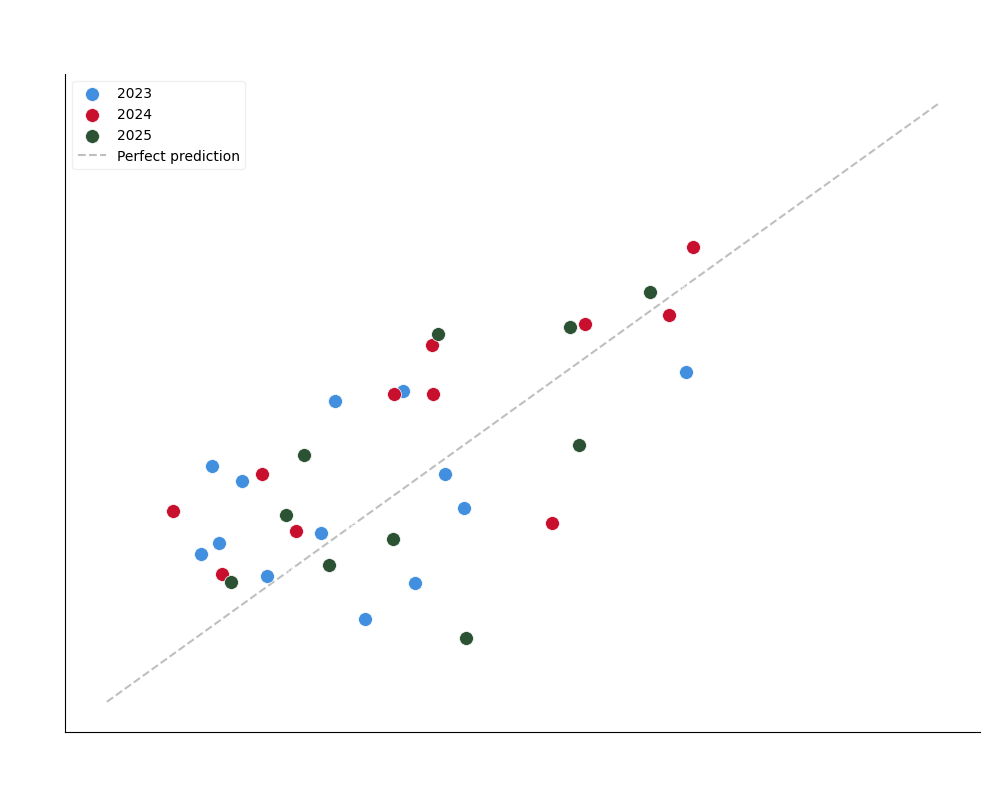

Saved!


In [12]:
import matplotlib.pyplot as plt
# Save backtest results
test_df[['player', 'draft_year', 'draft_pick', 'RIS', 'predicted_RIS', 'error', 'abs_error']].to_csv(
    "../data/processed/backtest_results.csv", index=False)
print("Saved backtest_results.csv!")

# Visualize predicted vs actual
fig, ax = plt.subplots(figsize=(10, 8))

colors = {2023: '#418FDE', 2024: '#C8102E', 2025: '#2C5234'}

for year in backtest_classes:
    year_df = test_df[test_df['draft_year'] == year]
    ax.scatter(year_df['RIS'], year_df['predicted_RIS'], 
               color=colors[year], s=100, label=str(year),
               edgecolors='white', linewidth=0.5, zorder=5)
    for _, row in year_df.iterrows():
        ax.annotate(row['player'].split()[-1],
                   (row['RIS'], row['predicted_RIS']),
                   textcoords="offset points", xytext=(5, 3),
                   fontsize=7, color='white', alpha=0.8)

# Perfect prediction line
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='Perfect prediction')

ax.set_xlabel('Actual RIS', fontsize=12, color='white')
ax.set_ylabel('Predicted RIS', fontsize=12, color='white')
ax.set_title('Historical Accuracy — Predicted vs Actual RIS\n2023-2025 Draft Classes', 
             fontsize=14, color='white', pad=20)
ax.legend(fontsize=10, framealpha=0.3)
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.style.use('dark_background')

plt.tight_layout()
plt.savefig('../visuals/backtest_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")